In [4]:
import torch
from transformers import CLIPProcessor, CLIPModel
from transformers import AutoProcessor, AutoModel
from PIL import Image
import matplotlib.pyplot as plt
import shapiq 
import src
import open_clip

import src
import src.game_huggingface
import src.game_openclip

import os

In [ ]:
from datasets import load_dataset
from huggingface_hub import login

login(token=os.getenv("HF_TOKEN"))

ds = load_dataset("redlessone/Derm1M")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [10]:
ds["train"][0]

{'filename': 'IIYI/26549_2.png',
 'caption': 'Male, 15 years old, has been experiencing spontaneous blistering all over his body since childhood, which heals and forms flat scars as shown in the attached image. The self-assumed diagnosis is dystrophic epidermolysis bullosa, based on a 10-year-old photo with no other available information. Other users and specialists in the forum agree with the diagnosis of dystrophic epidermolysis bullosa, although only photographic evidence was used to support this conclusion.',
 'truncated_caption': 'Male, 15 years old, has been experiencing spontaneous blistering all over his body since childhood, which heals and forms flat scars as shown in the attached image. The self-assumed diagnosis is dystrophic epidermolysis bullosa, based on a 10-year-old photo with no other available information. Other users and specialists in the forum agree with the diagnosis of dystrophic epidermolysis bullosa, although only photographic evidence was used to support this

In [11]:
# LOAD DERMLIP
model_dermlip, _, preprocess_dermlip = open_clip.create_model_and_transforms('hf-hub:redlessone/DermLIP_ViT-B-16')
model_dermlip.eval()

image = preprocess_dermlip(Image.open("tested_images/0d_59_PMC4458964_IJD_60_321e_g003_0.png")).unsqueeze(0)
# Initialize tokenizer
tokenizer_dermlip = open_clip.get_tokenizer('hf-hub:redlessone/DermLIP_ViT-B-16')

# Read example image

# Define disease labels (example: PAD dataset classes)
PAD_CLASSNAMES = [
    "nevus",
    "basal cell carcinoma",
    "actinic keratosis",
    "seborrheic keratosis",
    "squamous cell carcinoma",
    "melanoma"
]

# Build text prompts
template = lambda c: f'This is a skin image of {c}'
text = tokenizer_dermlip([template(c) for c in PAD_CLASSNAMES])

# Inference
with torch.no_grad(), torch.autocast("cuda"):
    # Encode image and text
    image_features = model_dermlip.encode_image(image)
    text_features = model_dermlip.encode_text(text)
    
    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    
    # Compute similarity
    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

# Get prediction
final_prediction = PAD_CLASSNAMES[torch.argmax(text_probs[0])]
print(f'This image is diagnosed as {final_prediction}.')
print("Label probabilities:", text_probs)

This image is diagnosed as nevus.
Label probabilities: tensor([[0.4391, 0.0087, 0.0382, 0.2123, 0.0077, 0.2939]])


In [ ]:
pubmed_filenames = [
    # "00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
    # "00_39_PMC10381143_jimaging-09-00148-g012_1.jpg",
    "0d_59_PMC4458964_IJD_60_321e_g003_0.png"
]

IYII_filenames = [
    # "2281_1.png"
]

youtube_filenames = [
    # "OzBKmWt9zWo_frame_8071_0_0.jpg"
]

download_tasks = {
    "pubmed": pubmed_filenames,
    "IIYI": IYII_filenames,
    "youtube": youtube_filenames
}

# Fetch all filenames from the training split
all_filenames = ds["train"]["filename"]

data = []

print("Searching for images in the dataset...\n")

for category, filenames in download_tasks.items():
    for target in filenames:
        found = False
        
        # In the dataset, filenames usually look like: "pubmed/00_39_PMC..." 
        # or "IIYI/2281_1.png" depending on the zip they come from.
        search_target = f"{category}/{target}"
        
        # Iterate through all filenames to find a substring match
        for idx, ds_filename in enumerate(all_filenames):
            if ds_filename and search_target in ds_filename:
                
                # Format to match your local structure: derm_train_images/{category}/{filename}
                data.append({
                    "filename": f"derm_train_images/{category}/{target}", 
                    "index": idx
                })
                
                found = True
                break  # Move to the next target once found
                
        if not found:
            print(f"[!] Not found: {search_target}")

import json
print("data =", json.dumps(data, indent=4))

Searching for images in the dataset...

data = [
    {
        "filename": "derm_train_images/pubmed/00_39_PMC10381143_jimaging-09-00148-g011_1.jpg",
        "index": 151106
    },
    {
        "filename": "derm_train_images/pubmed/00_39_PMC10381143_jimaging-09-00148-g012_1.jpg",
        "index": 8350
    },
    {
        "filename": "derm_train_images/pubmed/0d_59_PMC4458964_IJD_60_321e_g003_0.png",
        "index": 132556
    },
    {
        "filename": "derm_train_images/IIYI/2281_1.png",
        "index": 126
    },
    {
        "filename": "derm_train_images/youtube/OzBKmWt9zWo_frame_8071_0_0.jpg",
        "index": 321
    }
]


In [15]:
print(ds["train"][data[0]["index"]])

{'filename': 'pubmed/00_39_PMC10381143_jimaging-09-00148-g011_1.jpg', 'caption': "(b) Experts' annotation mask of milia-like cyst (MLC).", 'truncated_caption': "(b) Experts' annotation mask of milia-like cyst (MLC).", 'source': 'pubmed_fail', 'source_type': 'knowledge', 'disease_label': 'cyst, milia', 'hierarchical_disease_label': 'proliferations, benign, non-melanocytic, cyst, milia', 'skin_concept': 'No visual concepts', 'body_location': 'No body location information', 'symptoms': 'No symptom information', 'age': 'No age information', 'gender': 'No gender information'}



[hf-hub:redlessone/DermLIP_ViT-B-16] Loading Model...

  -> Processing sample 151106: derm_train_images/pubmed/00_39_PMC10381143_jimaging-09-00148-g011_1.jpg
PAD_TOKEN:  0
     [ Game Initialized ] TextPlayers=19, ImagePlayers=196
     [ Computing Interaction Values... ]
     [ Generating Explainer Plot ]


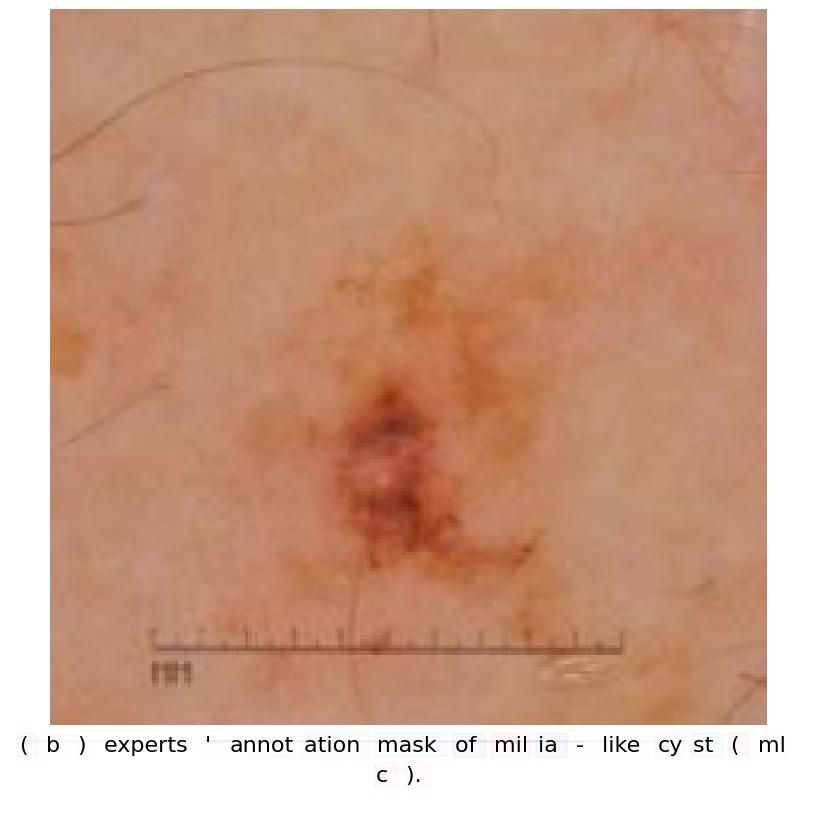


  -> Processing sample 8350: derm_train_images/pubmed/00_39_PMC10381143_jimaging-09-00148-g012_1.jpg
PAD_TOKEN:  0
     [ Game Initialized ] TextPlayers=12, ImagePlayers=196
     [ Computing Interaction Values... ]
     [ Generating Explainer Plot ]


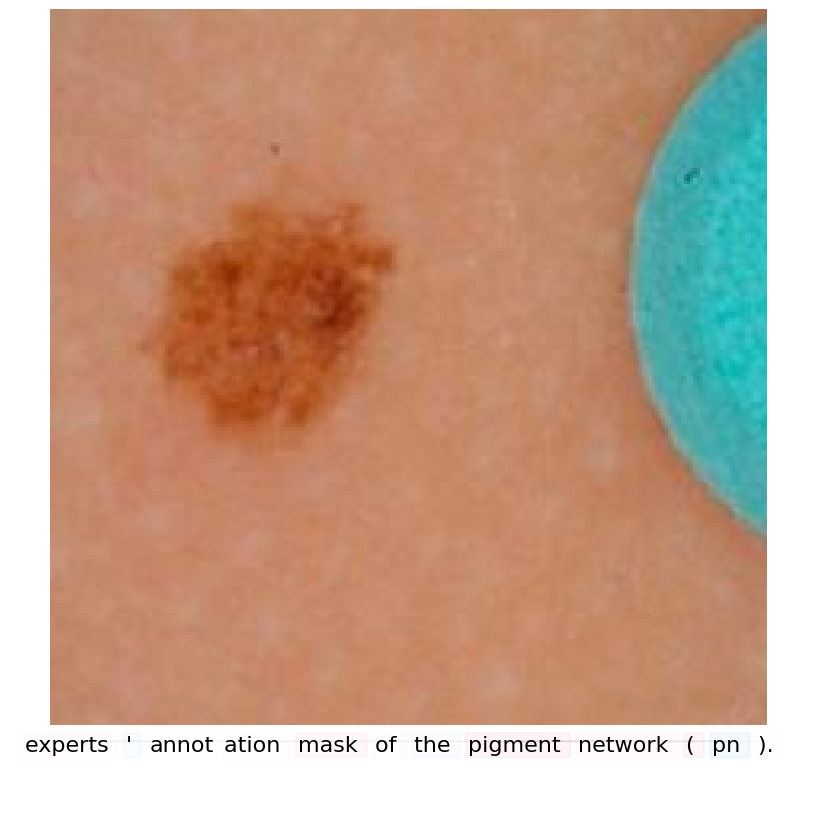


  -> Processing sample 132556: derm_train_images/pubmed/0d_59_PMC4458964_IJD_60_321e_g003_0.png
PAD_TOKEN:  0
     [ Game Initialized ] TextPlayers=10, ImagePlayers=196
     [ Computing Interaction Values... ]


In [ ]:
import src.utils
import src.plot
import matplotlib.pyplot as plt

# Define your list of models to test
models_to_test = [
    {"name": "hf-hub:redlessone/DermLIP_ViT-B-16", "backend": "open_clip"},
    # {"name": "openai/clip-vit-base-patch32", "backend": "huggingface"}
]

results = {}

for model_info in models_to_test:
    model_name = model_info["name"]
    backend = model_info["backend"]
    print(f"\n{'='*60}\n[{model_name}] Loading Model...\n{'='*60}")

    # ==========================================
    # 1. Load Model dynamically based on backend
    # ==========================================
    if backend == "huggingface":
        model = AutoModel.from_pretrained(model_name).to('cuda').eval()
        processor = AutoProcessor.from_pretrained(model_name)
        tokenizer = processor # HF uses combined processors
        image_mean = processor.image_processor.image_mean
        image_std = processor.image_processor.image_std
    else: # open_clip
        model, _, processor = open_clip.create_model_and_transforms(model_name)
        model = model.to('cuda').eval()
        tokenizer = open_clip.get_tokenizer(model_name)
        
        image_mean = (0.48145466, 0.4578275, 0.40821073)
        image_std = (0.26862954, 0.26130258, 0.27577711)
        
        patch_size = 16 
        if hasattr(model.visual, 'patch_size'):
            if isinstance(model.visual.patch_size, tuple):
                patch_size = model.visual.patch_size[0]
            else:
                patch_size = model.visual.patch_size

    results[model_name] = []

    # ==========================================
    # 2. Iterate over samples
    # ==========================================
    for item in data:
        img_path = item["filename"]
        idx = item["index"]
        print(f"\n  -> Processing sample {idx}: {img_path}")
        sample = ds["train"][idx]
        input_text = sample["caption"]
                
        try:
            input_image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            print(f"     [!] Image not found at {img_path}. Skipping.")
            continue

        # ==========================================
        # 3. Create the Game
        # ==========================================
        if backend == "huggingface":
            game = src.game_huggingface.VisionLanguageGame(
                model=model,
                processor=processor,
                input_image=input_image,
                input_text=input_text,
                batch_size=32 
            )
        else:
            game = src.game_openclip.OpenCLIPGame(
                model=model,
                image_processor=processor,
                text_tokenizer=tokenizer,
                input_image=input_image,
                input_text=input_text,
                patch_size=patch_size,
                batch_size=32 
            )

        print(f"     [ Game Initialized ] TextPlayers={game.n_players_text}, ImagePlayers={game.n_players_image}")

        # ==========================================
        # 4. Compute Explanations via FIxLIP 
        # ==========================================
        approximator = src.fixlip.FIxLIP(
            n_players_text=game.n_players_text,
            n_players_image=game.n_players_image,
            random_state=42
        )
        
        print(f"     [ Computing Interaction Values... ]")
        interaction_values = approximator.approximate_crossmodal(
            game=game,
            budget_image=2**11, # 2048 samples
            budget_text=2**6,   # 64 samples
            approximation_type="proxyshap"
        )
        
        results[model_name].append({
            "idx": idx,
            "filename": sample["filename"],
            "interaction_values": interaction_values
        })
        
        # ==========================================
        # 5. Extract Details & Visualize
        # ==========================================
        # Extract Text Tokens (strip boundaries based on n_players_text)
        if backend == "huggingface":
            text_tokens = game.inputs.tokens()
        else:
            if hasattr(tokenizer, "decode"):
                token_ids = tokenizer(input_text)[0]
                text_tokens = [tokenizer.decode([t.item()]) for t in token_ids]
            else:
                text_tokens = tokenizer(input_text)[0].numpy().tolist()
                text_tokens = [str(t) for t in text_tokens]

        if len(text_tokens) > game.n_players_text:
            text_tokens = text_tokens[1:game.n_players_text+1]
        
        text_tokens = [tok.replace('</w>', '').replace('<|startoftext|>', '').replace('<|endoftext|>', '') for tok in text_tokens]
        
        if backend == "huggingface":
            input_image_processed = game.inputs['pixel_values'].squeeze(0)
        else:
            input_image_processed = game.inputs[0].squeeze(0)
        input_image_denormalized = src.utils.denormalize(
            input_image_processed, 
            image_mean, 
            image_std
        ).permute(1, 2, 0).numpy()
        
        # Plot Heatmap & Word importances
        print(f"     [ Generating Explainer Plot ]")
        src.plot.plot_image_and_text_together(
            img=input_image_denormalized,
            text=text_tokens,
            image_players=list(range(game.n_players_image)),
            iv=interaction_values,
            plot_interactions=True,
            top_k=14,
            normalize_jointly=True,
            figsize=(8, 8),
            fontsize=16,
            margin=0.3,
            color_text=True,
            plot_heatmap=True,
            show=True,
            max_value=max(1.0, float(interaction_values.values.max() * 0.8)) # Flexible max scaling 
        )
        plt.tight_layout(pad=0.15)
        plt.show()

print(f"\n[{model_name}] Finished!\n")

# Free memory
del model
del processor
if backend == "open_clip":
    del tokenizer
torch.cuda.empty_cache()

In [13]:
print(results)

{'hf-hub:redlessone/DermLIP_ViT-B-16': [{'idx': 202352, 'filename': 'pubmed/00_39_PMC10381143_jimaging-09-00148-g011_0.jpg', 'interaction_values': InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=131072,
    n_players=204, baseline_value=24.718517303466797
)}, {'idx': 151106, 'filename': 'pubmed/00_39_PMC10381143_jimaging-09-00148-g011_1.jpg', 'interaction_values': InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=131072,
    n_players=215, baseline_value=24.280134201049805
)}, {'idx': 8350, 'filename': 'pubmed/00_39_PMC10381143_jimaging-09-00148-g012_1.jpg', 'interaction_values': InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=True, estimation_budget=131072,
    n_players=208, baseline_value=24.3498477935791
)}], 'openai/clip-vit-base-patch32': [{'idx': 202352, 'filename': 'pubmed/00_39_PMC10381143_jimaging-09-00148-g011_0.jpg', 'interaction_values': InteractionValues(
   